In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn nltk spacy textstat textblob gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 82.4 MB/s eta 0:00:00


In [2]:
!wget -q https://sites.cs.ucsb.edu/~william/data/liar_dataset.zip
!unzip -q liar_dataset.zip -d liar_dataset

In [3]:
import os

for root, dirs, files in os.walk("liar_dataset"):
    print(root)
    for file in files:
        print("   ", file)

liar_dataset
    test.tsv
    valid.tsv
    train.tsv
    README


In [4]:
import pandas as pd

columns = [
    "label",
    "statement",
    "subject",
    "speaker",
    "speaker_job_title",
    "state_info",
    "party_affiliation",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context"
]

train_df = pd.read_csv(
    "liar_dataset/train.tsv",
    sep="\t",
    header=None,
    names=columns
)

valid_df = pd.read_csv(
    "liar_dataset/valid.tsv",
    sep="\t",
    header=None,
    names=columns
)

test_df = pd.read_csv(
    "liar_dataset/test.tsv",
    sep="\t",
    header=None,
    names=columns
)

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Test shape:", test_df.shape)

Train shape: (10240, 13)
Validation shape: (1284, 13)
Test shape: (1267, 13)


In [5]:
train_df.head()

,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [6]:
print("Train labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(valid_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

Train labels:
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64

Validation labels:
label
false          263
mostly-true    251
half-true      248
barely-true    237
true           169
pants-fire     116
Name: count, dtype: int64

Test labels:
label
half-true      265
false          249
mostly-true    241
barely-true    212
true           208
pants-fire      92
Name: count, dtype: int64


In [7]:
print("===== DATASET INFORMATION =====")

print("\nTrain:")
print(train_df.info())

print("\nMissing values:")
print(train_df.isnull().sum())

print("\nDuplicate statements:")
print("Train:", train_df["statement"].duplicated().sum())
print("Validation:", valid_df["statement"].duplicated().sum())
print("Test:", test_df["statement"].duplicated().sum())

===== DATASET INFORMATION =====

Train:
<class 'pandas.core.frame.DataFrame'>
Index: 10240 entries, 2635.json to 1155.json
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   label                 10240 non-null  object 
 1   statement             10240 non-null  object 
 2   subject               10238 non-null  object 
 3   speaker               10238 non-null  object 
 4   speaker_job_title     7342 non-null   object 
 5   state_info            8030 non-null   object 
 6   party_affiliation     10238 non-null  object 
 7   barely_true_counts    10238 non-null  float64
 8   false_counts          10238 non-null  float64
 9   half_true_counts      10238 non-null  float64
 10  mostly_true_counts    10238 non-null  float64
 11  pants_on_fire_counts  10238 non-null  float64
 12  context               10138 non-null  object 
dtypes: float64(5), object(8)
memory usage: 1.3+ MB
None

Missing values:
label

label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64


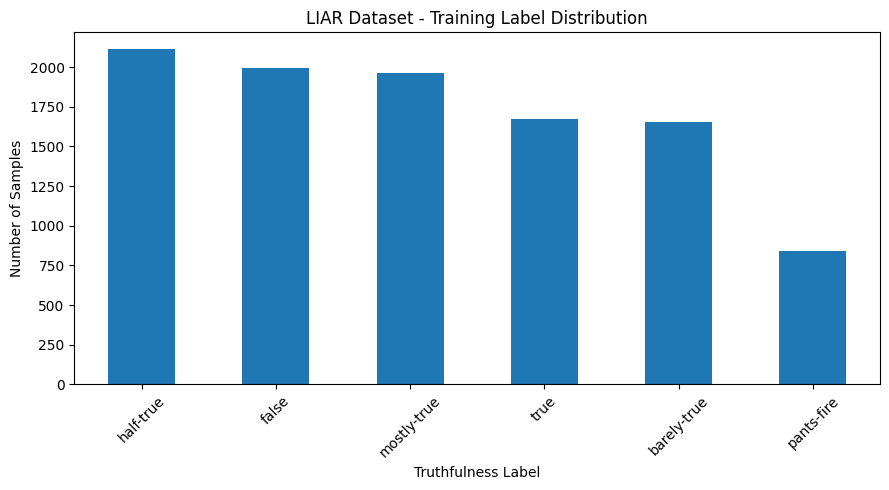

In [8]:
import matplotlib.pyplot as plt

label_counts = train_df["label"].value_counts()

print(label_counts)

plt.figure(figsize=(9, 5))
label_counts.plot(kind="bar")
plt.title("LIAR Dataset - Training Label Distribution")
plt.xlabel("Truthfulness Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
train_df["statement_length"] = train_df["statement"].fillna("").str.len()
train_df["word_count"] = train_df["statement"].fillna("").str.split().str.len()

print("Average characters:", train_df["statement_length"].mean())
print("Average words:", train_df["word_count"].mean())
print("Maximum words:", train_df["word_count"].max())
print("Minimum words:", train_df["word_count"].min())

Average characters: 106.91875
Average words: 18.01005859375
Maximum words: 467
Minimum words: 2


In [10]:
fake_labels = [
    "pants-fire",
    "false",
    "barely-true",
    "half-true"
]

real_labels = [
    "mostly-true",
    "true"
]

def convert_to_binary(label):
    if label in fake_labels:
        return "Fake"
    elif label in real_labels:
        return "Real"
    return None


train_df["binary_label"] = train_df["label"].apply(convert_to_binary)
valid_df["binary_label"] = valid_df["label"].apply(convert_to_binary)
test_df["binary_label"] = test_df["label"].apply(convert_to_binary)

print("Train binary distribution:")
print(train_df["binary_label"].value_counts())

print("\nValidation binary distribution:")
print(valid_df["binary_label"].value_counts())

print("\nTest binary distribution:")
print(test_df["binary_label"].value_counts())

Train binary distribution:
binary_label
Fake    6602
Real    3638
Name: count, dtype: int64

Validation binary distribution:
binary_label
Fake    864
Real    420
Name: count, dtype: int64

Test binary distribution:
binary_label
Fake    818
Real    449
Name: count, dtype: int64


In [11]:
print(
    train_df["binary_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

binary_label
Fake    64.47
Real    35.53
Name: proportion, dtype: float64


In [12]:
# Combine official LIAR train, validation and test sets

full_df = pd.concat(
    [train_df, valid_df, test_df],
    ignore_index=True
)

print("Combined dataset shape:", full_df.shape)

print("\nBinary label distribution:")
print(full_df["binary_label"].value_counts())

print("\nBinary label percentage:")
print(
    full_df["binary_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Combined dataset shape: (12791, 16)

Binary label distribution:
binary_label
Fake    8284
Real    4507
Name: count, dtype: int64

Binary label percentage:
binary_label
Fake    64.76
Real    35.24
Name: proportion, dtype: float64


In [13]:
before = len(full_df)

full_df = full_df.dropna(
    subset=["statement", "binary_label"]
).reset_index(drop=True)

after = len(full_df)

print("Rows before cleaning:", before)
print("Rows removed:", before - after)
print("Rows after cleaning:", after)

Rows before cleaning: 12791
Rows removed: 0
Rows after cleaning: 12791


In [14]:
duplicates = full_df["statement"].duplicated().sum()

print("Duplicate statements:", duplicates)

Duplicate statements: 26


In [15]:
before = len(full_df)

full_df = full_df.drop_duplicates(
    subset=["statement"],
    keep="first"
).reset_index(drop=True)

after = len(full_df)

print("Rows before removing duplicates:", before)
print("Duplicate rows removed:", before - after)
print("Rows after removing duplicates:", after)

print("\nFinal binary distribution:")
print(full_df["binary_label"].value_counts())

print("\nFinal percentages:")
print(
    full_df["binary_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Rows before removing duplicates: 12791
Duplicate rows removed: 26
Rows after removing duplicates: 12765

Final binary distribution:
binary_label
Fake    8263
Real    4502
Name: count, dtype: int64

Final percentages:
binary_label
Fake    64.73
Real    35.27
Name: proportion, dtype: float64


In [16]:
print("Missing statements:", full_df["statement"].isnull().sum())
print("Missing binary labels:", full_df["binary_label"].isnull().sum())
print("Duplicate statements:", full_df["statement"].duplicated().sum())
print("Total samples:", len(full_df))

Missing statements: 0
Missing binary labels: 0
Duplicate statements: 0
Total samples: 12765


In [17]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temporary
train_data, temp_data = train_test_split(
    full_df,
    test_size=0.20,
    stratify=full_df["binary_label"],
    random_state=42
)

# Second split: temporary 20% into 10% validation + 10% test
valid_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    stratify=temp_data["binary_label"],
    random_state=42
)

print("Train:", train_data.shape)
print("Validation:", valid_data.shape)
print("Test:", test_data.shape)

Train: (10212, 16)
Validation: (1276, 16)
Test: (1277, 16)


In [18]:
for name, df in [
    ("Train", train_data),
    ("Validation", valid_data),
    ("Test", test_data)
]:
    print(f"\n{name}")
    print(df["binary_label"].value_counts())
    print(
        (df["binary_label"]
         .value_counts(normalize=True)
         .mul(100)
         .round(2))
    )


Train
binary_label
Fake    6610
Real    3602
Name: count, dtype: int64
binary_label
Fake    64.73
Real    35.27
Name: proportion, dtype: float64

Validation
binary_label
Fake    826
Real    450
Name: count, dtype: int64
binary_label
Fake    64.73
Real    35.27
Name: proportion, dtype: float64

Test
binary_label
Fake    827
Real    450
Name: count, dtype: int64
binary_label
Fake    64.76
Real    35.24
Name: proportion, dtype: float64


In [19]:
train_statements = set(train_data["statement"])
valid_statements = set(valid_data["statement"])
test_statements = set(test_data["statement"])

print("Train ∩ Validation:", len(train_statements & valid_statements))
print("Train ∩ Test:", len(train_statements & test_statements))
print("Validation ∩ Test:", len(valid_statements & test_statements))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [20]:
import os

os.makedirs("data/processed", exist_ok=True)

train_data.to_csv(
    "data/processed/train.csv",
    index=False
)

valid_data.to_csv(
    "data/processed/validation.csv",
    index=False
)

test_data.to_csv(
    "data/processed/test.csv",
    index=False
)

print("Dataset splits saved successfully!")

print("\nFiles:")
print("→ data/processed/train.csv")
print("→ data/processed/validation.csv")
print("→ data/processed/test.csv")

Dataset splits saved successfully!

Files:
→ data/processed/train.csv
→ data/processed/validation.csv
→ data/processed/test.csv


In [21]:
import os

for file in [
    "data/processed/train.csv",
    "data/processed/validation.csv",
    "data/processed/test.csv"
]:
    print(file, "→", os.path.getsize(file), "bytes")

data/processed/train.csv → 2570183 bytes
data/processed/validation.csv → 319585 bytes
data/processed/test.csv → 323640 bytes


In [23]:
import os

project = "NewsGuard-Fake-News-Detection"

folders = [
    project,
    f"{project}/data/raw",
    f"{project}/data/processed",
    f"{project}/notebooks",
    f"{project}/src",
    f"{project}/app",
    f"{project}/models",
    f"{project}/results/figures",
    f"{project}/results/metrics",
    f"{project}/results/predictions",
    f"{project}/reports",
    f"{project}/tests",
    f"{project}/mlruns"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ NewsGuard project structure created!")

✅ NewsGuard project structure created!


In [24]:
import shutil
import os

source_folder = "data/processed"
target_folder = "NewsGuard-Fake-News-Detection/data/processed"

for file in [
    "train.csv",
    "validation.csv",
    "test.csv"
]:
    source = os.path.join(source_folder, file)
    target = os.path.join(target_folder, file)

    if os.path.exists(source):
        shutil.copy2(source, target)
        print(f"✅ Copied: {file}")
    else:
        print(f"⚠️ Not found: {source}")

✅ Copied: train.csv
✅ Copied: validation.csv
✅ Copied: test.csv


In [25]:
import os

print(os.listdir("NewsGuard-Fake-News-Detection/data/processed"))

['validation.csv', 'test.csv', 'train.csv']
